### Random Forest Classifier

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import LabelEncoder


In [3]:
# Load the dataset
data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
df = pd.read_csv(data_url)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,crop
0,17.0,136.0,196.0,23.871923,90.499390,5.882156,103.054809,apple
1,49.0,69.0,82.0,18.315615,15.361435,7.263119,81.787105,chickpea
2,74.0,49.0,38.0,23.314104,71.450905,7.488014,164.497037,jute
3,104.0,35.0,28.0,27.510061,50.666872,6.983732,143.995555,coffee
4,23.0,72.0,84.0,19.020613,17.131591,6.920251,79.926981,chickpea


In [4]:
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

X = df[feature_cols]
y = df['crop']

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y_encoded  # Maintain class distribution
)

print(f"\nTraining set: {X_train.shape[0]})")
print(f"Test set: {X_test.shape[0]}")


Training set: 1320)
Test set: 330


In [8]:
model = RandomForestClassifier(
    n_estimators=100,        # Number of trees in the forest
    max_depth=10,            # Maximum depth of each tree
    min_samples_split=5,     # Minimum samples required to split a node
    min_samples_leaf=2,      # Minimum samples required in a leaf node
    max_features='sqrt',     # Number of features to consider for best split
    bootstrap=True,          # Whether to use bootstrap samples
    # oob_score=True,          # Use out-of-bag samples for accuracy estimation
    random_state=42,
    n_jobs=-1                # Use all available CPU cores
)

# Train the model
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [10]:
y_pred = model.predict(X_test)
# y_pred_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.9939
Precision: 0.9947
Recall:    0.9939
F1-Score:  0.9939


In [13]:
# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=4, scoring='accuracy')
print(cv_scores)
print(cv_scores.mean().round(4))

[0.98305085 0.99515738 1.         0.99514563]
0.9933


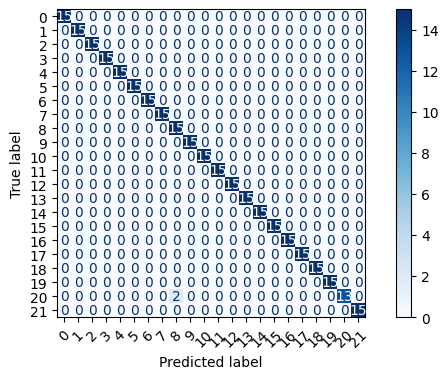

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))
cm = confusion_matrix(y_test, y_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp1.plot(ax=axes, cmap='Blues', xticks_rotation=45)


       Feature  Importance
6     rainfall    0.223889
4     humidity    0.212657
2            K    0.179619
1            P    0.147387
0            N    0.105182
3  temperature    0.079595
5           ph    0.051670


([<matplotlib.patches.Wedge at 0x75f33c1151f0>,
 [Text(0.8389339175264066, 0.7114702256762377, 'rainfall'),
  Text(-0.5312494469504129, 0.9632102704575366, 'humidity'),
  Text(-1.0849511297248933, -0.18133131585216578, 'K'),
  Text(-0.40583970385700163, -1.0223962709112653, 'P'),
  Text(0.44410785548886145, -1.0063638570085298, 'N'),
  Text(0.9232862866040576, -0.5979485203333899, 'temperature'),
  Text(1.0855393294710534, -0.17777616311400138, 'ph')],
 [Text(0.45760031865076717, 0.3880746685506751, '22.4%'),
  Text(-0.28977242560931604, 0.5253874202495653, '21.3%'),
  Text(-0.5917915253044872, -0.09890799046481769, '18.0%'),
  Text(-0.22136711119472813, -0.5576706932243265, '14.7%'),
  Text(0.24224064844846985, -0.5489257401864708, '10.5%'),
  Text(0.5036107017840313, -0.3261537383636671, '8.0%'),
  Text(0.5921123615296654, -0.09696881624400074, '5.2%')])

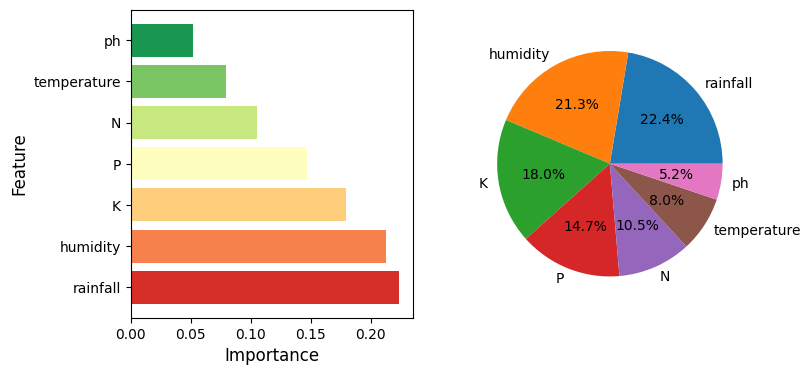

In [20]:
# Create feature importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# Plot 1: Horizontal Bar Chart
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(feature_cols)))
axes[0].barh(importance_df['Feature'], importance_df['Importance'], color=colors)
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)
# axes[0].set_title('Feature Importance', fontsize=14, fontweight='bold')

# Plot 2: Pie Chart
axes[1].pie(
    importance_df['Importance'], 
    labels=importance_df['Feature'],
    autopct='%1.1f%%',
)

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [10, 25, 50, 75, 100],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    verbose=1,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)

# Evaluate
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print(f"Accuracy: {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall: {recall_final:.4f}")
print(f"F1 Score: {f1_final:.4f}")

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 25}
Best CV score: 0.9947
Accuracy: 0.9939
Precision: 0.9947
Recall: 0.9939
F1 Score: 0.9939


In [24]:
import joblib
from pathlib import Path

model_obj = globals().get("best_model")
output_path = Path("../../models/random_forest.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")

Saved model to: /media/kushagra/DATA/notebook/crop-recommendation-ml-system/models/random_forest.pkl


In [26]:
sample_input = [[17.0,  136.0,  196.0,    23.871923,  90.499390,  5.882156,  103.054809]]  # N, P, K, temperature, humidity, ph, rainfall
prediction = best_model.predict(sample_input)
print(f"Predicted crop: {label_encoder.inverse_transform([prediction[0]])[0]}")

Predicted crop: apple


/media/kushagra/DATA/notebook/crop-recommendation-ml-system/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
